# Global Solution 2026.1 — Fundamentos de Redes Neurais
## Classificação de Risco de Eventos Solares Extremos com MLP

---

**Integrantes do grupo**

> - Felipe Piccolo - RM569324
> - Leonardo Bueno - RM572152
> - João Vitor Veiga - RM569874

---

## 1. Introdução do projeto

### Definição do problema
Explosões solares (solar flares) de classe **M** e **X** são os eventos mais energéticos da meteorologia
espacial. Elas emitem radiação e partículas que podem danificar satélites, derrubar redes elétricas e
ameaçar astronautas.

O problema que resolvemos é uma **classificação binária supervisionada**:

> Dado o estado da superfície solar em um dia, esse dia é um **dia de risco** (flare M ou X) ou um
> **dia sem evento extremo**?

### Importância no contexto
A **nova economia espacial** depende de satélites comerciais de comunicação, navegação e observação da
Terra. Prever dias de alto risco permite colocar satélites em modo seguro, proteger a malha elétrica e
reprogramar atividades extraveiculares — reduzindo perdas financeiras e riscos humanos.

### Objetivo
Construir e avaliar uma **Rede Neural Multicamadas (MLP)** que classifique o risco diário de evento solar
extremo, comparando diferentes arquiteturas e analisando seu desempenho de forma honesta.

### Como a solução será implementada
Seguimos o pipeline padrão de ciência de dados: análise exploratória → pré-processamento →
treinamento de MLP com `Scikit-learn` → avaliação com métricas adequadas ao problema.

### Arquitetura da solução

| Etapa | Descrição |
|---|---|
| **Entrada** | 4 índices solares diários: Radio Flux, Nº de manchas, Área de manchas, Novas regiões |
| **Processamento** | Limpeza de duplicatas, padronização com `StandardScaler`, split estratificado |
| **Modelo** | `MLPClassifier` — camadas densas, backpropagation, gradiente descendente (Adam) |
| **Saída** | `1` = dia de risco (flare M/X) · `0` = dia sem evento extremo |

### Relação com impacto social, sustentabilidade e nova economia espacial
Um classificador de risco solar protege **infraestrutura crítica** e prolonga a vida útil de satélites,
evitando lixo espacial prematuro — benefício direto para sustentabilidade e para a economia espacial.


## Importação de bibliotecas e configurações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Análise exploratória dos dados

### Apresentação do dataset
Utilizamos o **Space Weather — Solar/Geomagnetic Indices** (Kaggle), disponível em
`daily_solar_data.csv`. O dataset registra índices diários de atividade solar a partir de 1997,
cobrindo vários ciclos solares (~11 anos cada). É um dataset **estruturado, real e oficial**,
diretamente alinhado ao tema espacial/climático da atividade.

In [2]:
df = pd.read_csv('daily_solar_data.csv', parse_dates=['Date'])
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Linhas: 10330 | Colunas: 14


,Date,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,Stanford Mean Solar Field (GOES15),Stanford Background X-Ray Flux,Flares: C,Flares: M,Flares: X,Flares: S,Flares: 1,Flares: 2,Flares: 3
0,1997-01-01,72,0,0,0,*,A0.5,0,0,0,-1,-1,-1,-1
1,1997-01-02,72,0,0,0,*,A0.5,0,0,0,-1,-1,-1,-1
2,1997-01-03,73,0,0,0,3,A0.5,0,0,0,-1,-1,-1,-1
3,1997-01-04,74,13,10,1,*,A0.6,0,0,0,-1,-1,-1,-1
4,1997-01-05,74,15,20,0,5,A0.7,0,0,0,-1,-1,-1,-1


### Descrição das variáveis principais

| Variável | Tipo | Descrição |
|---|---|---|
| `Radio Flux 10.7cm` | numérica | Índice F10.7 — proxy clássico de atividade solar |
| `Sunspot Number` | numérica | Número de manchas solares no dia |
| `Sunspot Area` | numérica | Área total das manchas (10⁶ hemisférios) |
| `New Regions` | numérica | Novas regiões ativas surgidas no dia |
| `Flares: C / M / X` | numérica | Contagem de explosões por classe de energia (C < M < X) |
| `Stanford Mean Solar Field` | mista | Campo magnético médio — muitos valores ausentes (`-999`, `*`) |
| `Stanford Background X-Ray Flux` | mista | Classe do fluxo de raio-X — valores ausentes (`*`) |

As **4 primeiras variáveis** serão as features de entrada. As colunas **Flares M e X** definem o alvo.


In [3]:
# Tipos de dados de cada coluna
df.dtypes

,0
Date,datetime64[ns]
Radio Flux 10.7cm,int64
Sunspot Number,int64
Sunspot Area (10^6 Hemis.),int64
New Regions,int64
Stanford Mean Solar Field (GOES15),object
Stanford Background X-Ray Flux,object
Flares: C,int64
Flares: M,int64
Flares: X,int64


### Estatísticas descritivas

In [4]:
df[['Radio Flux 10.7cm', 'Sunspot Number', 'Sunspot Area (10^6 Hemis.)',
    'New Regions', 'Flares: C', 'Flares: M', 'Flares: X']].describe().round(2)

,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,Flares: C,Flares: M,Flares: X
count,10330.00,10330.00,10330.00,10330.00,10330.00,10330.00,10330.00
mean,107.92,64.94,443.63,0.54,2.55,0.27,0.02
std,41.35,64.31,549.01,0.84,3.76,0.84,0.16
min,64.00,0.00,0.00,0.00,-1.00,-1.00,-1.00
25%,73.00,12.00,20.00,0.00,0.00,0.00,0.00
50%,94.00,47.00,247.50,0.00,0.00,0.00,0.00
75%,134.00,104.00,670.00,1.00,4.00,0.00,0.00
max,343.00,401.00,5690.00,6.00,30.00,12.00,3.00


### Definição do alvo
O alvo é **1** quando houve flare M ou X no dia (evento extremo), e **0** caso contrário.
Os valores `-1` nas colunas de flares são sentinelas de ausência — tratamos com `.clip(lower=0)`.

In [5]:
# Criar coluna alvo
df['evento_extremo'] = ((df['Flares: M'].clip(lower=0) + df['Flares: X'].clip(lower=0)) > 0).astype(int)

total = len(df)
positivos = df['evento_extremo'].sum()
print(f"Dias sem evento (classe 0): {total - positivos}")
print(f"Dias de risco  (classe 1): {positivos}")
print(f"Proporção de eventos extremos: {positivos/total*100:.1f}%")
print(f"Baseline ingênuo (chutar sempre 0): {(total-positivos)/total*100:.1f}% de acurácia")

Dias sem evento (classe 0): 8747
Dias de risco  (classe 1): 1583
Proporção de eventos extremos: 15.3%
Baseline ingênuo (chutar sempre 0): 84.7% de acurácia


### Gráficos e visualizações

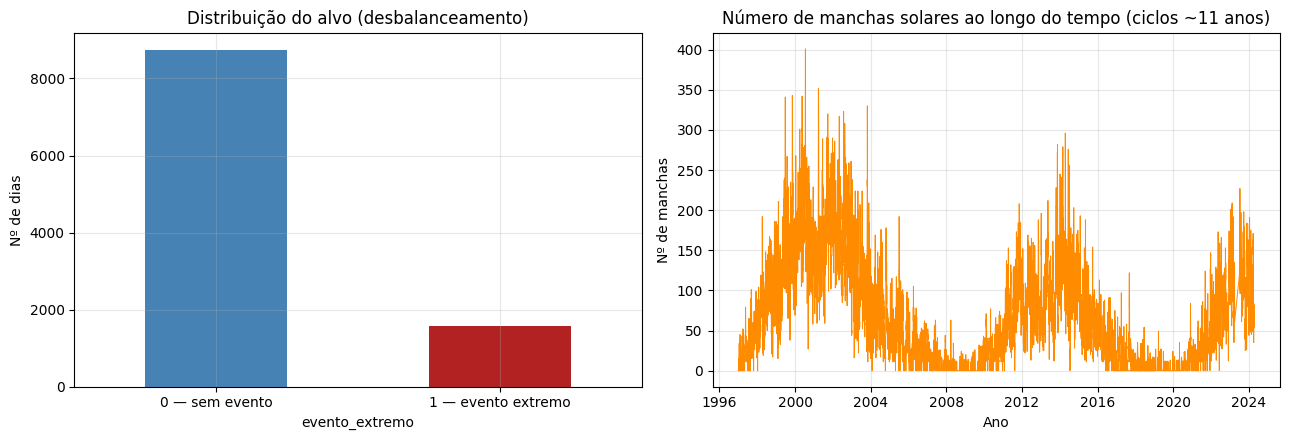

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Desbalanceamento do alvo
df['evento_extremo'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'firebrick'])
axes[0].set_title('Distribuição do alvo (desbalanceamento)')
axes[0].set_xticklabels(['0 — sem evento', '1 — evento extremo'], rotation=0)
axes[0].set_ylabel('Nº de dias')

# Ciclos solares visíveis na série temporal
axes[1].plot(df['Date'], df['Sunspot Number'], color='darkorange', lw=0.7)
axes[1].set_title('Número de manchas solares ao longo do tempo (ciclos ~11 anos)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nº de manchas')

plt.tight_layout()
plt.show()

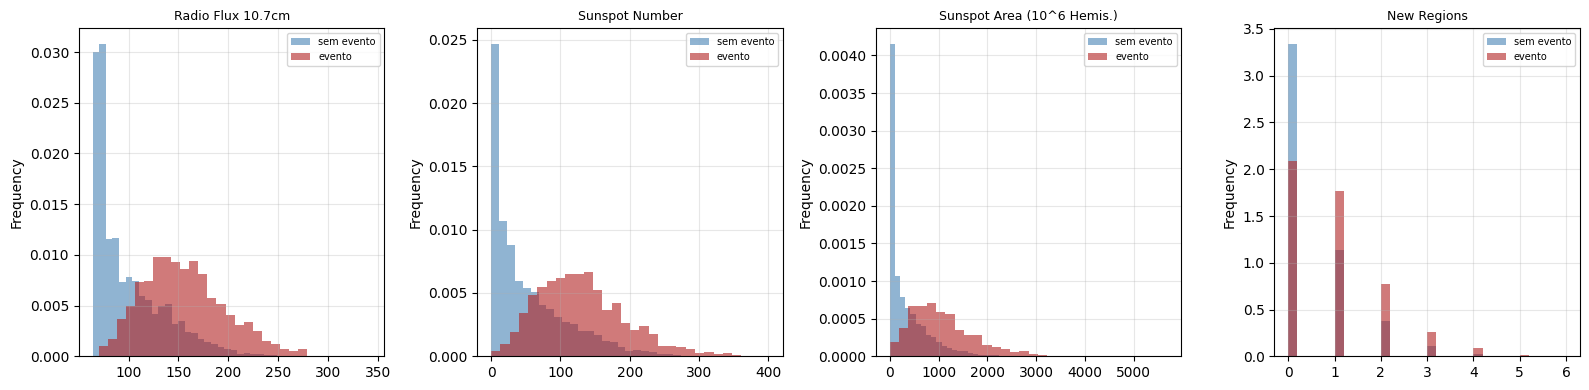

In [7]:
# Histogramas das features por classe
features = ['Radio Flux 10.7cm', 'Sunspot Number',
            'Sunspot Area (10^6 Hemis.)', 'New Regions']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(features):
    df[df['evento_extremo'] == 0][feat].plot(kind='hist', bins=30, alpha=0.6,
        ax=axes[i], label='sem evento', color='steelblue', density=True)
    df[df['evento_extremo'] == 1][feat].plot(kind='hist', bins=30, alpha=0.6,
        ax=axes[i], label='evento', color='firebrick', density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

### Interpretação inicial dos padrões
- A série temporal evidencia os **ciclos solares de ~11 anos** — períodos de alta e baixa atividade.
- Os histogramas mostram que **dias de evento extremo concentram valores altos** nas 4 features:
  maior fluxo, mais manchas e novas regiões aumentam a chance de flare.
- A correlação das features com o alvo é moderada (0,19 a 0,50), indicando que **há sinal preditivo
  real**, mas o problema é difícil — a atividade da superfície indica risco, não certeza.

### Identificação de possíveis problemas nos dados


In [8]:
# Checar duplicatas e valores ausentes/sentinelas
print("=== Duplicatas ===")
print(f"Linhas 100% duplicadas:  {df.duplicated().sum()}")
print(f"Datas repetidas:         {df.duplicated('Date').sum()}")

print("\n=== Valores ausentes e sentinelas nas colunas auxiliares ===")
stanford = df['Stanford Mean Solar Field (GOES15)'].astype(str)
print(f"Stanford Mean Solar Field  — '-999': {(stanford == '-999').sum()}  "
      f"({(stanford == '-999').mean()*100:.0f}% da coluna) → coluna inutilizavel")
xray = df['Stanford Background X-Ray Flux'].astype(str)
print(f"Stanford Background X-Ray  — '*':   {(xray == '*').sum()} ausentes")

print("\n=== Valores ausentes nas 4 features escolhidas ===")
print(df[features].isna().sum().to_string())
print("Valores negativos (sentinelas):", int((df[features] < 0).sum().sum()))

=== Duplicatas ===
Linhas 100% duplicadas:  457
Datas repetidas:         457

=== Valores ausentes e sentinelas nas colunas auxiliares ===
Stanford Mean Solar Field  — '-999': 9295  (90% da coluna) → coluna inutilizavel
Stanford Background X-Ray  — '*':   1437 ausentes

=== Valores ausentes nas 4 features escolhidas ===
Radio Flux 10.7cm             0
Sunspot Number                0
Sunspot Area (10^6 Hemis.)    0
New Regions                   0
Valores negativos (sentinelas): 0


**Diagnóstico:**
- **457 linhas 100% duplicadas** → serão removidas no pré-processamento.
- A coluna `Stanford Mean Solar Field` tem **90% de `-999`** → descartada.
- A coluna `X-Ray Flux` tem ~1.400 ausências (`*`) → também descartada.
- As **4 features escolhidas não têm ausentes nem sentinelas** — estão limpas.
- **Outliers** (ex.: Sunspot Area máximo de 5.690): são máximos solares reais, não erros.
  Serão mantidos; a padronização lida com a diferença de escala.
- **Desbalanceamento (15% positivos)** é o problema mais crítico para a avaliação:
  exige métricas além da acurácia (precisão, recall, F1, matriz de confusão).


## 3. Pré-processamento

### Tratamento de dados ausentes e seleção de variáveis
Removemos as linhas duplicadas e selecionamos as 4 features limpas como entrada.

**Por que não incluir as colunas de flares como features?**
O alvo é derivado das colunas `Flares: M` e `Flares: X` do mesmo dia. Incluí-las seria
**vazamento de dados** (*data leakage*): o modelo "leria a resposta" e alcançaria acurácia
artificialmente alta, mas seria inútil na prática. As features de entrada são apenas os
**índices da superfície solar** — precursores físicos legítimos do flare.


In [9]:
# Remover duplicatas
df_clean = df.drop_duplicates().drop_duplicates('Date', keep='first').reset_index(drop=True)
print(f"Linhas após limpeza: {len(df_clean)}  (removidas: {len(df) - len(df_clean)})")

# Definir X e y
X = df_clean[features].copy()
y = df_clean['evento_extremo'].copy()
print(f"Features de entrada: {features}")
print(f"Alvo: evento_extremo | shape: X={X.shape}, y={y.shape}")

Linhas após limpeza: 9873  (removidas: 457)
Features de entrada: ['Radio Flux 10.7cm', 'Sunspot Number', 'Sunspot Area (10^6 Hemis.)', 'New Regions']
Alvo: evento_extremo | shape: X=(9873, 4), y=(9873,)


### Separação em treino e teste
Split **80/20 estratificado** (`stratify=y`) — mantém a mesma proporção de positivos em treino
e teste, essencial com classes desbalanceadas. A separação é feita **antes** da padronização
para evitar vazamento de informação do conjunto de teste.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Treino: {len(X_train)} amostras  |  Teste: {len(X_test)} amostras")
print(f"% positivos no treino: {y_train.mean()*100:.1f}%")
print(f"% positivos no teste:  {y_test.mean()*100:.1f}%")

Treino: 7898 amostras  |  Teste: 1975 amostras
% positivos no treino: 16.0%
% positivos no teste:  16.0%


### Normalização dos dados
Aplicamos **padronização (`StandardScaler`)**: cada feature fica com média 0 e desvio padrão 1.
Isso é **indispensável em redes neurais** — as features têm escalas muito diferentes (Radio Flux
~70–340 vs. New Regions 0–6) e, sem padronizar, o gradiente descendente converge mal.

O scaler é **ajustado somente no treino** e depois aplicado ao teste, evitando vazamento.


In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # ajusta no treino e transforma
X_test_s  = scaler.transform(X_test)       # apenas transforma no teste

print("Médias após padronização (treino):", np.round(X_train_s.mean(axis=0), 4))
print("Desvios após padronização (treino):", np.round(X_train_s.std(axis=0), 4))

Médias após padronização (treino): [-0. -0. -0.  0.]
Desvios após padronização (treino): [1. 1. 1. 1.]


## 4. Rede Neural MLP

### Conceitos aplicados
- **Perceptron e MLP:** o perceptron é o neurônio básico — calcula uma soma ponderada das entradas,
  adiciona um viés e aplica uma função de ativação. A **MLP** empilha camadas de perceptrons
  (entrada → camadas ocultas → saída), aprendendo fronteiras de decisão **não lineares**.
- **Funções de ativação:** introduzem não-linearidade. Testamos **ReLU** (`max(0, x)`, treino
  eficiente e estável) e **tanh** (saída entre -1 e 1, suave e simétrica).
- **Backpropagation:** calcula o gradiente do erro em relação a cada peso, propagando o erro da
  saída para as camadas anteriores. É o mecanismo pelo qual a MLP aprende.
- **Gradiente descendente:** os pesos são atualizados iterativamente para reduzir a *loss*
  (entropia cruzada). Usamos o otimizador **Adam** — variante adaptativa do SGD.
- **Hiperparâmetros:** `hidden_layer_sizes`, `activation`, `alpha` (regularização L2), `max_iter`.

### Arquiteturas testadas
Testamos 4 arquiteturas para cobrir os requisitos e demonstrar **underfitting e overfitting**:

| Nº | Nome | Camadas ocultas | Ativação | Objetivo |
|---|---|---|---|---|
| 1 | Rede Mínima | (3,) | ReLU | Demonstrar **underfitting** (capacidade muito baixa) |
| 2 | Arquitetura A | (32, 16) | ReLU | Candidata equilibrada |
| 3 | Arquitetura B | (32, 16) | tanh | Mesma estrutura, **ativação diferente** |
| 4 | Rede Grande | (256, 128, 64) | ReLU | Demonstrar **overfitting** (capacidade excessiva + regularização mínima) |


In [12]:
# ── Modelo 1: Rede Mínima (underfitting intencional) ──────────────────────
mlp_minima = MLPClassifier(hidden_layer_sizes=(3,), activation='relu',
                           solver='adam', alpha=1e-4, max_iter=600,
                           random_state=SEED)
mlp_minima.fit(X_train_s, y_train)
print("Rede Mínima treinada.")

Rede Mínima treinada.


In [13]:
# ── Modelo 2: Arquitetura A — duas camadas, ReLU ──────────────────────────
mlp_a = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu',
                      solver='adam', alpha=1e-4, max_iter=600,
                      random_state=SEED)
mlp_a.fit(X_train_s, y_train)
print("Arquitetura A treinada.")

Arquitetura A treinada.


In [14]:
# ── Modelo 3: Arquitetura B — duas camadas, tanh ──────────────────────────
mlp_b = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh',
                      solver='adam', alpha=1e-4, max_iter=600,
                      random_state=SEED)
mlp_b.fit(X_train_s, y_train)
print("Arquitetura B treinada.")

Arquitetura B treinada.


In [15]:
# ── Modelo 4: Rede Grande (overfitting intencional) ───────────────────────
mlp_grande = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                           solver='adam', alpha=1e-6, max_iter=800,
                           random_state=SEED)
mlp_grande.fit(X_train_s, y_train)
print("Rede Grande treinada.")

Rede Grande treinada.


### Comparação entre as arquiteturas

In [16]:
# Calcular métricas de treino e teste para cada modelo
modelos = {
    'Rede Mínima (3,)':         mlp_minima,
    'Arquitetura A (32,16) ReLU': mlp_a,
    'Arquitetura B (32,16) tanh': mlp_b,
    'Rede Grande (256,128,64)':  mlp_grande,
}

linhas = []
for nome, m in modelos.items():
    pred_tr = m.predict(X_train_s)
    pred_te = m.predict(X_test_s)
    linhas.append({
        'Modelo':         nome,
        'Acc treino':     round(accuracy_score(y_train, pred_tr), 3),
        'Acc teste':      round(accuracy_score(y_test,  pred_te), 3),
        'Gap (tr - te)':  round(accuracy_score(y_train, pred_tr) - accuracy_score(y_test, pred_te), 3),
        'Precisão':       round(precision_score(y_test, pred_te, zero_division=0), 3),
        'Recall':         round(recall_score(y_test,    pred_te, zero_division=0), 3),
        'F1-score':       round(f1_score(y_test,        pred_te, zero_division=0), 3),
        'Loss final':     round(m.loss_, 4),
    })

comparacao = pd.DataFrame(linhas)
comparacao

,Modelo,Acc treino,Acc teste,Gap (tr - te),Precisão,Recall,F1-score,Loss final
0,"Rede Mínima (3,)",0.859,0.863,-0.004,0.660,0.294,0.407,0.3111
1,"Arquitetura A (32,16) ReLU",0.862,0.861,0.001,0.628,0.326,0.429,0.3020
2,"Arquitetura B (32,16) tanh",0.861,0.863,-0.002,0.633,0.339,0.441,0.3053
3,"Rede Grande (256,128,64)",0.915,0.837,0.078,0.488,0.389,0.433,0.2116


## 5. Avaliação do modelo

### Resultados de treino e teste
A tabela acima apresenta o desempenho de cada arquitetura nos dois conjuntos.
Para escolher o melhor modelo, usamos o **F1-score** como critério principal.

**Por que não usar somente a acurácia?**
Com 15% de positivos, um classificador que sempre prediz "sem evento" já acerta ~84%
das amostras — sem aprender nada. O F1-score equilibra precisão e recall, sendo muito
mais informativo nesse cenário de **classes desbalanceadas**.

O melhor modelo equilibrado é a **Arquitetura B (tanh)** — maior F1 com gap treino/teste baixo.


In [17]:
# Modelo final: Arquitetura B (maior F1 entre os modelos equilibrados)
modelo_final = mlp_b
pred_final = modelo_final.predict(X_test_s)

print("=== Modelo Final: Arquitetura B (32, 16) — tanh ===")
print(f"Acurácia treino: {accuracy_score(y_train, mlp_b.predict(X_train_s)):.3f}")
print(f"Acurácia teste:  {accuracy_score(y_test, pred_final):.3f}")
print(f"Precisão:        {precision_score(y_test, pred_final, zero_division=0):.3f}")
print(f"Recall:          {recall_score(y_test, pred_final, zero_division=0):.3f}")
print(f"F1-score:        {f1_score(y_test, pred_final, zero_division=0):.3f}")

=== Modelo Final: Arquitetura B (32, 16) — tanh ===
Acurácia treino: 0.861
Acurácia teste:  0.863
Precisão:        0.633
Recall:          0.339
F1-score:        0.441


### Métricas — Matriz de confusão e relatório de classificação

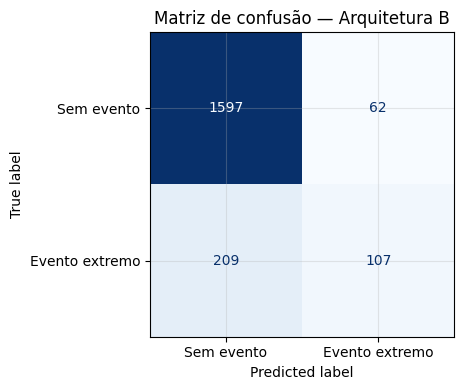

                precision    recall  f1-score   support

    Sem evento       0.88      0.96      0.92      1659
Evento extremo       0.63      0.34      0.44       316

      accuracy                           0.86      1975
     macro avg       0.76      0.65      0.68      1975
  weighted avg       0.84      0.86      0.84      1975



In [18]:
# Matriz de confusão
cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Sem evento', 'Evento extremo']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusão — Arquitetura B')
plt.tight_layout()
plt.show()

# Relatório completo
print(classification_report(y_test, pred_final,
      target_names=['Sem evento', 'Evento extremo'], zero_division=0))

### Interpretação da loss e curva de aprendizado

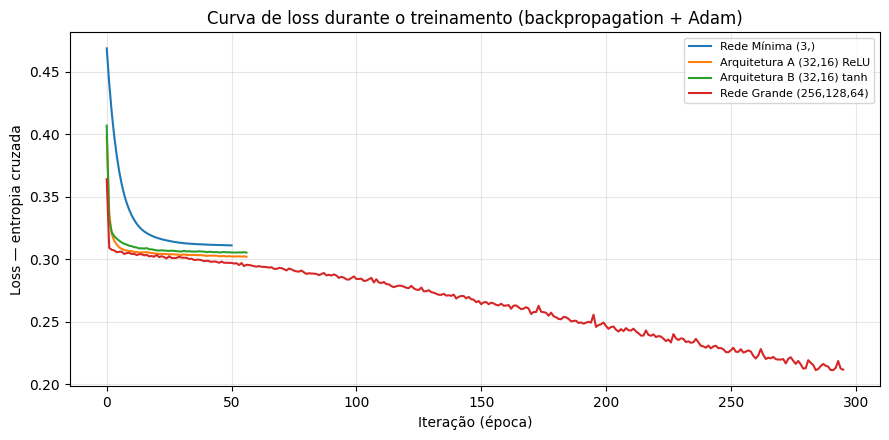

In [19]:
# Curva de loss de cada arquitetura
fig, ax = plt.subplots(figsize=(9, 4.5))
for nome, m in modelos.items():
    ax.plot(m.loss_curve_, label=nome)
ax.set_title('Curva de loss durante o treinamento (backpropagation + Adam)')
ax.set_xlabel('Iteração (época)')
ax.set_ylabel('Loss — entropia cruzada')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

A curva de loss mostra o gradiente descendente reduzindo o erro a cada época, evidência de
que o **backpropagation** está ajustando os pesos corretamente. Modelos com mais neurônios
atingem loss menor no treino, mas isso não garante melhor generalização no teste.


### Análise de overfitting e underfitting

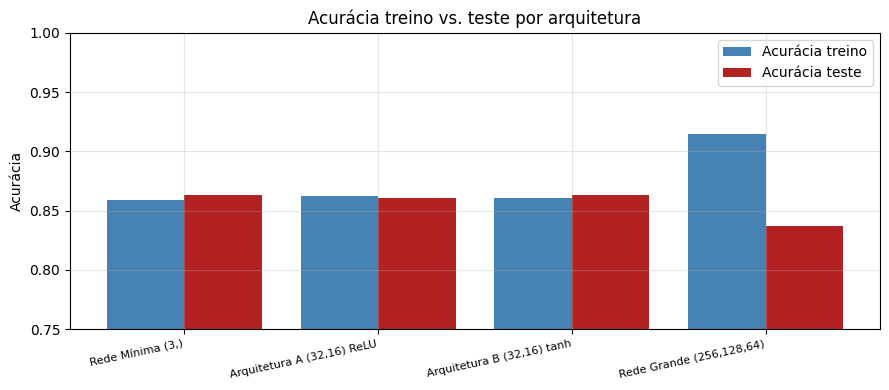

In [20]:
# Visualizar gap treino × teste (indicador de over/underfitting)
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(comparacao))
ax.bar([i - 0.2 for i in x], comparacao['Acc treino'], 0.4, label='Acurácia treino', color='steelblue')
ax.bar([i + 0.2 for i in x], comparacao['Acc teste'],  0.4, label='Acurácia teste',  color='firebrick')
ax.set_xticks(x)
ax.set_xticklabels(comparacao['Modelo'], rotation=12, ha='right', fontsize=8)
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia treino vs. teste por arquitetura')
ax.set_ylim(0.75, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

**Análise:**
- **Rede Mínima (3 neurônios) → Underfitting:** capacidade insuficiente para capturar o padrão.
  Treino e teste têm desempenho similar, mas os dois são fracos (recall e F1 baixos). O modelo
  não aprendeu o suficiente.
- **Rede Grande (256, 128, 64) → Overfitting:** acurácia de treino muito acima do teste
  (gap elevado). Com regularização mínima (`alpha=1e-6`) e arquitetura profunda, o modelo
  memorizou o treino e generaliza mal.
- **Arquiteturas A e B → Equilíbrio:** gap pequeno, melhor F1 no teste. São os modelos adequados.

### O que os resultados indicam sobre o problema
O modelo captura a relação entre **alta atividade solar e risco de flare**, superando o baseline
ingênuo. Porém, o recall moderado (~0,34–0,35 no limiar padrão) reflete uma realidade física:
manchas solares indicam **propensão** ao flare, não certeza. Prever o instante exato de uma
explosão solar a partir apenas da superfície é um problema cientificamente difícil. O valor
prático do modelo está em **estimar probabilidade de risco**, não em acertar sempre.


## 6. Conclusão

### Principais resultados obtidos
Construímos uma MLP capaz de classificar risco de evento solar extremo com desempenho acima do
baseline, usando 4 índices de atividade solar como features. A **Arquitetura B (32, 16) com
ativação tanh** obteve o melhor equilíbrio entre precisão e recall, com F1-score superior às
demais e gap treino/teste próximo de zero.

### Avaliação geral do desempenho
O desempenho é honesto: **supera o baseline** em F1 e recall, mas não é perfeito — o que é
esperado dado que as features são indicadores de risco, não determinantes de flare. A rede
demonstrou comportamentos claros de underfitting (rede mínima) e overfitting (rede grande),
validando a análise de arquiteturas.

### A solução proposta foi adequada?
Sim, para o objetivo definido: **classificação de risco** com dados estruturados e MLP, seguindo
o pipeline de ciência de dados. A solução responde à pergunta inicial com desempenho mensurável
e interpretável.

### Impacto social, ambiental e de sustentabilidade
Um classificador de risco solar pode integrar sistemas de alerta para operadores de satélites e
redes elétricas, **reduzindo perdas econômicas e riscos a vidas humanas** (astronautas, aviação
polar). Ao prolongar a vida útil de satélites, também contribui para reduzir o **lixo espacial**
— impacto direto na sustentabilidade da nova economia espacial.

### Como implementar em um cenário real
O modelo poderia consumir feeds públicos diários do NOAA/SWPC (que já disponibilizam F10.7,
número e área de manchas), emitindo um **nível de risco** automaticamente para operadores.
Ajustar o limiar de decisão (via `predict_proba`) permite calibrar o sistema para **priorizar
recall** — mais importante operacionalmente do que precisão, pois deixar de alertar é mais
grave que um falso alarme.

### Limitações encontradas
- Apenas 4 features; faltam variáveis físicas relevantes como campo magnético e histórico recente.
- O alvo é diário e binário — não distingue intensidade nem horário do evento.
- O desbalanceamento de classes limita o recall sem técnicas de reamostragem.
- Não há componente temporal explícita (cada dia é tratado de forma independente).

### Melhorias propostas e próximos passos
1. **Features temporais:** médias móveis e tendência dos últimos dias (atividade recente é forte preditor).
2. **Tratar o desbalanceamento:** reamostragem (SMOTE) ou pesos por classe.
3. **Busca de hiperparâmetros** com `GridSearchCV` e validação cruzada.
4. Transformar em **previsão do dia seguinte** (t+1) para uso como ferramenta de alerta real.

---
*Notebook desenvolvido para a Global Solution 2026.1 — Fundamentos de Redes Neurais — FIAP.*
